In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from neural_network.utils import build_covariance_matrix
from neural_network.trainer import SobolevTrainer
from neural_network.config import MarketParams, ModelConfig
from neural_network.payoff import PutProductMultipleAssets


In [2]:
n_assets = 3

S0 = 2.0
r = 0.1

stds = np.array([0.4, 0.5, 0.6])
correlation_matrix = np.array([
    [1.0, 0.6, 0.3],
    [0.6, 1.0, 0.5],
    [0.3, 0.5, 1.0]
])

sigma = build_covariance_matrix(stds, correlation_matrix)

K = 8.0
T = 1.0
S_min = 0.0
S_max = 3 * S0

market_params = MarketParams(n_assets=3, S0=S0, r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)

In [3]:
input_size = n_assets + 1
hidden_sizes = [64, 64, 64]
output_size = 1
activation = nn.Mish()
learning_rate = 0.001
model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate
)

In [4]:
put_product = PutProductMultipleAssets()
trainer_product = SobolevTrainer(model_config, market_params, put_product, 42)
trainer_product.train(batch_size=1000, epochs=5000, tol=1e-3)

Iteration 0, Loss: 231.0216064453125
Iteration 100, Loss: 61.246910095214844
Iteration 200, Loss: 10.350685119628906
Iteration 300, Loss: 6.2465362548828125
Iteration 400, Loss: 5.773399353027344
Iteration 500, Loss: 5.562952041625977
Iteration 600, Loss: 5.250952243804932
Iteration 700, Loss: 5.4555158615112305
Iteration 800, Loss: 4.645448207855225
Iteration 900, Loss: 4.388215065002441
Iteration 1000, Loss: 4.532988548278809
Converged at epoch 1009


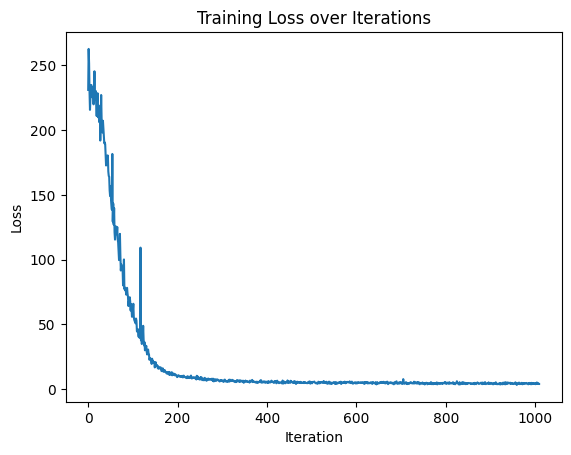

In [5]:
trainer_product.plot_losses()